In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch 
from torch import nn
import torch.nn  as nn
from sklearn.model_selection import train_test_split
import sklearn
from sklearn.datasets import make_circles

In [2]:
n_samples = 1000
X,y = make_circles(n_samples,noise=0.03,random_state=42)

<function Tensor.type>

In [4]:
print("First 5 features are: ",X[:5])
print("First 5 labels are: ",y[:5])

First 5 features are:  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 labels are:  [1 1 1 1 0]


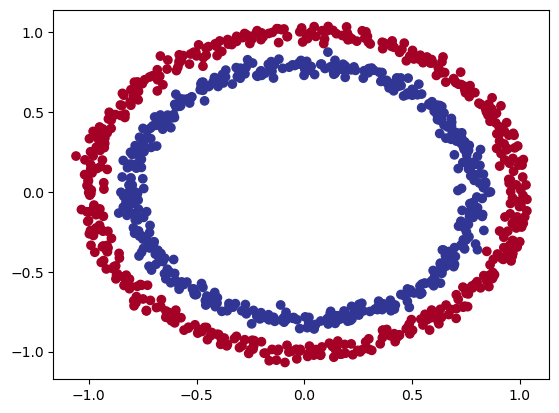

In [7]:
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap = plt.cm.RdYlBu)

In [9]:
circles = pd.DataFrame({"X1":X[:,0],"X2":X[:,1],"Label":y})
circles

,X1,X2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


In [15]:
X[:5],y[:5],X.dtype,y.dtype

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 array([1, 1, 1, 1, 0]),
 torch.float32,
 dtype('int64'))

In [16]:
y = torch.from_numpy(y).type(torch.float)

In [18]:
X.dtype,y.dtype,X.type,y.type

(torch.float32, torch.float32, <function Tensor.type>, <function Tensor.type>)

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [20]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [23]:
class NonLinearFn(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer1 = nn.Linear(in_features=2,out_features=10)
        self.linear_layer2 = nn.Linear(in_features = 10, out_features=10)
        self.linear_layer3 = nn.Linear(in_features = 10,out_features = 1)
        self.relu = nn.ReLU()
        
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer3(self.relu(self.linear_layer2(self.relu(self.linear_layer1(x)))))
    
    
model_0 = NonLinearFn()
model_0,model_0.state_dict()
        

(NonLinearFn(
   (linear_layer1): Linear(in_features=2, out_features=10, bias=True)
   (linear_layer2): Linear(in_features=10, out_features=10, bias=True)
   (linear_layer3): Linear(in_features=10, out_features=1, bias=True)
   (relu): ReLU()
 ),
 OrderedDict([('linear_layer1.weight',
               tensor([[ 0.6181, -0.5760],
                       [ 0.6391, -0.2822],
                       [-0.0867, -0.0149],
                       [ 0.0621,  0.0668],
                       [-0.1928, -0.4168],
                       [ 0.2634, -0.4924],
                       [ 0.4326,  0.4408],
                       [ 0.5131, -0.3801],
                       [-0.0969, -0.3529],
                       [ 0.1114, -0.5417]])),
              ('linear_layer1.bias',
               tensor([ 0.2796, -0.6661,  0.3040, -0.3807,  0.4441, -0.2451,  0.4604,  0.4601,
                        0.2680,  0.1940])),
              ('linear_layer2.weight',
               tensor([[ 0.0250, -0.1046, -0.1624, -0.2114,  0.080

In [24]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr = 0.1)


In [25]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy = correct / len(y_true) * 100
    return accuracy

In [26]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    # Forward pass
    model_0.train()
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    #Evaluate the Model
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc= accuracy_fn(y_true=y_test,y_pred=test_pred)
        
        
    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | Loss : {loss} | Train Acc : {acc} | Test Loss : {test_loss} | Test Acc : {test_acc}")
        
        

Epoch : 0 | Loss : 0.7006809711456299 | Train Acc : 52.125 | Test Loss : 0.6943833827972412 | Test Acc : 52.0
Epoch : 100 | Loss : 0.6930931806564331 | Train Acc : 48.25 | Test Loss : 0.6910545229911804 | Test Acc : 51.5
Epoch : 200 | Loss : 0.6900414824485779 | Train Acc : 52.0 | Test Loss : 0.6895850300788879 | Test Acc : 53.0
Epoch : 300 | Loss : 0.6869543194770813 | Train Acc : 52.125 | Test Loss : 0.6879308819770813 | Test Acc : 55.50000000000001
Epoch : 400 | Loss : 0.6841140985488892 | Train Acc : 54.0 | Test Loss : 0.6863563656806946 | Test Acc : 56.00000000000001
Epoch : 500 | Loss : 0.6804441809654236 | Train Acc : 55.875 | Test Loss : 0.6841637492179871 | Test Acc : 55.50000000000001
Epoch : 600 | Loss : 0.6751618981361389 | Train Acc : 57.125 | Test Loss : 0.6806071400642395 | Test Acc : 56.49999999999999
Epoch : 700 | Loss : 0.6661624908447266 | Train Acc : 66.625 | Test Loss : 0.6740173101425171 | Test Acc : 66.0
Epoch : 800 | Loss : 0.6526897549629211 | Train Acc : 73.75

Text(0.5, 1.0, 'Test')

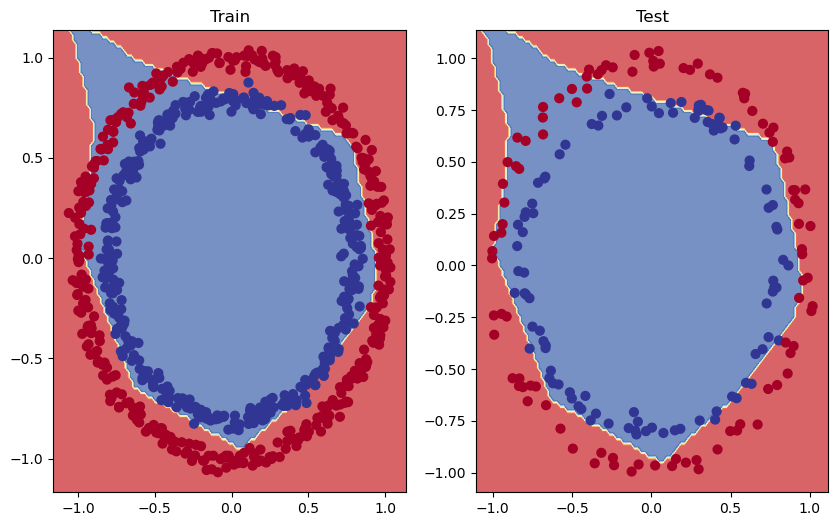

In [27]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plot_decision_boundary(model_0,X_train,y_train)
plt.title("Train")
plt.subplot(1,2,2)
plot_decision_boundary(model_0,X_test,y_test)
plt.title("Test")